In [26]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import logging
import time
import seaborn as sns
from sklearn.decomposition import PCA, TruncatedSVD

In [3]:
# Set up logging
# This configuration is for all modules that are in the same Python process, so it will affect all logging calls in this notebook
# To ensure all files use the same logging configuration, we can create a main.py file that sets up logging and then import the logger from there in all other files. 
logging.basicConfig(level=logging.INFO,
                    # filename='autoencoder_training.log',
                    # filemode='w',
                    format='%(levelname)s: %(message)s',
                    force=True) # Force reconfiguration to ensure settings are applied

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logging.info(f"Using device: {device}")

INFO: Using device: cpu


In [6]:
logger = logging.getLogger(__name__) # Create a logger for the current file
logger.setLevel(logging.INFO) # Set the logging level to INFO for this logger
logger.info(f"Logger name: {logger.name} and level: {logging.getLevelName(logger.level)}") # Log the logger's name and level to verify configuration

INFO: Logger name: __main__ and level: INFO


In [7]:
time_variant_df = pd.read_csv('../datasets/all_features_all_data.csv')

if time_variant_df.empty:
    logger.warning("The loaded DataFrame is empty. Please check the file path and contents.")
else:
    logger.info(f"Data loaded successfully with shape: {time_variant_df.shape}")
    logger.info(f'DataFrame columns: {time_variant_df.columns.tolist()}')

INFO: Data loaded successfully with shape: (79152, 193)
INFO: DataFrame columns: ['city', 'state', 'zip', 'latitude_x', 'longitude_x', 'time', 'us_aqi', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'uv_index_clear_sky', 'uv_index', 'dust', 'aerosol_optical_depth', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'cloud_cover', 'road_distance_m', 'road_impact_score', 'facility_count_nearby', 'facility_impact_score', 'overall_spatial_impact_score', 'month', 'month_sin', 'month_cos', 'day', 'hour', 'hour_sin', 'hour_cos', 'day_of_week', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year', 'is_weekend', 'wind_direction_10m_sin', 'wind_direction_10m_cos', 'wind_direction_100m_sin', 'wind_direction_100m_cos', 'latitude_y', 'longitude_y', 'us_aqi_past_1', 'us_aqi_past_2', 'us_aqi_past_3', 'us_aqi_past_4', 'us_aqi_past_5', 'us_aqi_past_6', 'us_aqi_

In [8]:
# Delete NaN values in the DataFrame
time_variant_df.dropna(inplace=True)
logger.info(f"Data cleaned successfully with shape: {time_variant_df.shape}")


INFO: Data cleaned successfully with shape: (76824, 193)


In [9]:
time_variant_df.drop(columns=['latitude_y', 'longitude_y', 'city', 'state', 'month', 'day', 'hour', 'day_of_week', 'day_of_year'], inplace=True)
logger.info(f"Unnecessary columns dropped. Remaining columns: {time_variant_df.columns.tolist()}")

INFO: Unnecessary columns dropped. Remaining columns: ['zip', 'latitude_x', 'longitude_x', 'time', 'us_aqi', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'uv_index_clear_sky', 'uv_index', 'dust', 'aerosol_optical_depth', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'cloud_cover', 'road_distance_m', 'road_impact_score', 'facility_count_nearby', 'facility_impact_score', 'overall_spatial_impact_score', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'is_weekend', 'wind_direction_10m_sin', 'wind_direction_10m_cos', 'wind_direction_100m_sin', 'wind_direction_100m_cos', 'us_aqi_past_1', 'us_aqi_past_2', 'us_aqi_past_3', 'us_aqi_past_4', 'us_aqi_past_5', 'us_aqi_past_6', 'us_aqi_past_7', 'us_aqi_past_8', 'us_aqi_past_9', 'us_aqi_past_10', 'us_aqi_past_11', 'us_aqi_past_12', 'us_aqi_past_13', 'us_aqi_past

In [10]:
lag_prefixes = [
            'us_aqi_past_',
            'pm2_5_past_',
            'ozone_past_',
            'wind_speed_10m_past_',
            'wind_direction_10m_sin_past_',
            'wind_direction_10m_cos_past_',
        ]

lag_features = [col for col in time_variant_df.columns if any(col.startswith(prefix) for prefix in lag_prefixes)]
logger.info(f"Identified lag features: {lag_features}")



INFO: Identified lag features: ['us_aqi_past_1', 'us_aqi_past_2', 'us_aqi_past_3', 'us_aqi_past_4', 'us_aqi_past_5', 'us_aqi_past_6', 'us_aqi_past_7', 'us_aqi_past_8', 'us_aqi_past_9', 'us_aqi_past_10', 'us_aqi_past_11', 'us_aqi_past_12', 'us_aqi_past_13', 'us_aqi_past_14', 'us_aqi_past_15', 'us_aqi_past_16', 'us_aqi_past_17', 'us_aqi_past_18', 'us_aqi_past_19', 'us_aqi_past_20', 'us_aqi_past_21', 'us_aqi_past_22', 'us_aqi_past_23', 'us_aqi_past_24', 'pm2_5_past_1', 'pm2_5_past_2', 'pm2_5_past_3', 'pm2_5_past_4', 'pm2_5_past_5', 'pm2_5_past_6', 'pm2_5_past_7', 'pm2_5_past_8', 'pm2_5_past_9', 'pm2_5_past_10', 'pm2_5_past_11', 'pm2_5_past_12', 'pm2_5_past_13', 'pm2_5_past_14', 'pm2_5_past_15', 'pm2_5_past_16', 'pm2_5_past_17', 'pm2_5_past_18', 'pm2_5_past_19', 'pm2_5_past_20', 'pm2_5_past_21', 'pm2_5_past_22', 'pm2_5_past_23', 'pm2_5_past_24', 'ozone_past_1', 'ozone_past_2', 'ozone_past_3', 'ozone_past_4', 'ozone_past_5', 'ozone_past_6', 'ozone_past_7', 'ozone_past_8', 'ozone_past_9', 'o

In [12]:
remove_cols = ['zip', 'time', 'us_aqi'] + lag_features
feature_cols = [col for col in time_variant_df.columns if col not in remove_cols]
logger.info(f"Feature columns: {feature_cols}")
logger.info(f"Number of feature columns: {len(feature_cols)}")

INFO: Feature columns: ['latitude_x', 'longitude_x', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'uv_index_clear_sky', 'uv_index', 'dust', 'aerosol_optical_depth', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'cloud_cover', 'road_distance_m', 'road_impact_score', 'facility_count_nearby', 'facility_impact_score', 'overall_spatial_impact_score', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'is_weekend', 'wind_direction_10m_sin', 'wind_direction_10m_cos', 'wind_direction_100m_sin', 'wind_direction_100m_cos']
INFO: Number of feature columns: 37


In [32]:
# Group by 'zip', sort by 'time', and create sequences
train_splits = []
test_splits = []

for zip_code, group in time_variant_df.groupby('zip'):
    group = group.sort_values('time').reset_index(drop=True)
    split_index = int(len(group) * 0.8)
    train_splits.append(group.iloc[:split_index])
    test_splits.append(group.iloc[split_index:])

train_df = pd.concat(train_splits, axis=0).reset_index(drop=True) # Combine all training splits into a single DataFrame
test_df = pd.concat(test_splits, axis=0).reset_index(drop=True)

X_train = train_df[feature_cols].values
X_val = test_df[feature_cols].values
logger.info(f"Training split shape: {X_train.shape}")
logger.info(f"Validation split shape: {X_val.shape}")
logger.info(f'First training split sample:\n{train_df[feature_cols].iloc[0]}')

y_train = train_df['us_aqi'].values
y_val = test_df['us_aqi'].values
logger.info(f"Training labels shape: {y_train.shape}")
logger.info(f"Validation labels shape: {y_val.shape}")

INFO: Training split shape: (61401, 37)
INFO: Validation split shape: (15423, 37)
INFO: First training split sample:
latitude_x                        29.756350
longitude_x                      -95.365380
pm10                              31.300000
pm2_5                             30.900000
carbon_monoxide                  636.000000
nitrogen_dioxide                  78.000000
sulphur_dioxide                   11.300000
ozone                             15.000000
uv_index_clear_sky                 0.000000
uv_index                           0.000000
dust                               1.000000
aerosol_optical_depth              0.060000
temperature_2m                     9.900000
relative_humidity_2m              52.580440
precipitation                      0.000000
wind_speed_10m                     4.327493
wind_speed_100m                    9.059205
wind_gusts_10m                     8.280000
shortwave_radiation                0.000000
diffuse_radiation                  0.000000
clo

In [33]:
# Scale the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
logger.info("Feature scaling completed successfully.")
logger.info(f'Feature range after scaling: min={X_train_scaled.min()}, max={X_train_scaled.max()}')
logger.info(f'Feature range after scaling: min={X_val_scaled.min()}, max={X_val_scaled.max()}')

scaler2 = StandardScaler()
X_train_scaled_std = scaler2.fit_transform(X_train)
X_val_scaled_std = scaler2.transform(X_val)
logger.info("Feature scaling completed successfully.")
logger.info(f'Feature range after scaling: min={X_train_scaled_std.min()}, max={X_train_scaled_std.max()}')
logger.info(f'Feature range after scaling: min={X_val_scaled_std.min()}, max={X_val_scaled_std.max()}')



INFO: Feature scaling completed successfully.
INFO: Feature range after scaling: min=0.0, max=1.0000000000000002
INFO: Feature range after scaling: min=-0.006923837784371909, max=1.088235294117647


INFO: Feature scaling completed successfully.
INFO: Feature range after scaling: min=-3.133765495142954, max=24.820243072914945
INFO: Feature range after scaling: min=-2.7543317249940236, max=4.869495087669858


In [34]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
logger.info("Data converted to PyTorch tensors successfully.")

INFO: Data converted to PyTorch tensors successfully.


In [35]:
# Convert to PyTorch tensors
X_train_tensor_std = torch.tensor(X_train_scaled_std, dtype=torch.float32)
X_val_tensor_std = torch.tensor(X_val_scaled_std, dtype=torch.float32)
logger.info("Data converted to PyTorch tensors successfully.")

INFO: Data converted to PyTorch tensors successfully.


In [36]:
class EarlyStopping:
  def __init__(self, patience=5):
    self.patience = patience
    self.counter = 0;
    self.best_loss = float("inf")
    self.best_state = None
  
  def step(self, model, val_loss):
    if(val_loss < self.best_loss):
      self.best_loss = val_loss
      self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
      self.counter = 0
      return False
    else:
      self.counter += 1
      return self.counter >= self.patience

class TimeVariantAutoencoder(nn.Module):
    def __init__(self, input_dim, scaler=MinMaxScaler, hidden_layers=[128, 64]):
        super(TimeVariantAutoencoder, self).__init__()
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_layers[:-1]:
            encoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            encoder_layers.append(nn.ReLU())
            prev_dim = hidden_dim
        encoder_layers.append(nn.Linear(prev_dim, hidden_layers[-1])) # Final layer to latent space
        self.encoder = nn.Sequential(*encoder_layers)

        # Decoder
        decoder_layers = []
        prev_dim = hidden_layers[-1]
        for hidden_dim in reversed(hidden_layers[:-1]):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            decoder_layers.append(nn.ReLU())
            prev_dim = hidden_dim
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers, nn.Sigmoid()) if scaler == MinMaxScaler else nn.Sequential(*decoder_layers)

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return latent, reconstructed

In [44]:
class AETrainer:
    def __init__(self, input_dim, scaler=MinMaxScaler, hidden_layers=[128, 64]):
        self.model = TimeVariantAutoencoder(input_dim=input_dim, scaler=scaler, hidden_layers=hidden_layers).to(device)

    def compile(self, optimizer, loss_fn):
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.earlystopper = EarlyStopping()
    
    def loader(self, X, batch_size=1048, shuffle=True):
        dataset = TensorDataset(X)
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    
    def fit(self, X, val, num_epochs=50):
        history = {'train_loss': [], 'val_loss': [], 'best_loss': float('inf'), 'training_time': 0}
        start_time = time.time()

        self.model.train() # Set the model to training mode
        for epoch in range(num_epochs):
            epoch_loss = 0.0
            
            train_loader = self.loader(X)
            val_loader = self.loader(val, shuffle=False)
            
            for (X_batch, )in train_loader:
                _, reconstructed = self.model.forward(X_batch)

                self.optimizer.zero_grad()
                loss = self.loss_fn(reconstructed, X_batch)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item() * X_batch.size(0) # Accumulate loss
            
            avg_loss = epoch_loss / len(train_loader.dataset) # Average loss for the epoch
            history['train_loss'].append(avg_loss)

            val_loss = self.validate(val_loader)
            history['val_loss'].append(val_loss)

            if (epoch + 1) % 10 == 0 or epoch == 0: # Log every 10 epochs and the first epoch
                logger.info(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss:.8f}, , Val Loss: {val_loss:.8f}')

            if(self.earlystopper.step(self.model, val_loss)):
              logger.info(f"Early stopping at epoch {epoch+1}")
              break
        end_time = time.time()

        history['training_time'] = end_time - start_time
        history['best_loss'] = self.earlystopper.best_loss
        return history

    def validate(self, test):
        self.model.eval() # Set the model to evaluation mode
        val_loss = 0.0
        with torch.no_grad():
            for (X_batch, )in test:
                _, reconstructed = self.model.forward(X_batch)
                loss = self.loss_fn(reconstructed, X_batch)
                val_loss += loss.item() * X_batch.size(0) # len(X_batch) is the number of samples in the batch, so we multiply by it to get the total loss for that batch
        avg_loss = val_loss / len(test.dataset) # Average loss for the test set
        #logger.info(f'Val Loss: {avg_loss:.8f}')
        return avg_loss

            

In [68]:
hidden_layers = [
    [16],
    [8],
    # [16],
     [16, 4],
    # [128, 32],
    # [64, 32, 8]
]

In [69]:
results_minmax = []
results_std = []

for hidden_layer_config in hidden_layers:
    logger.info(f"Training autoencoder with hidden layers: {hidden_layer_config}")
    trainer_minmax = AETrainer(input_dim=X_train_tensor.shape[1], scaler=MinMaxScaler, hidden_layers=hidden_layer_config)
    trainer_minmax.compile(optimizer=torch.optim.Adam(trainer_minmax.model.parameters(), lr=0.001), loss_fn=nn.MSELoss())
    history = trainer_minmax.fit(X_train_tensor, X_val_tensor)
    results_minmax.append({
        'hidden_layers': hidden_layer_config,
        'train_loss': history['train_loss'],
        'val_loss': history['val_loss'], 
        'training_time': history['training_time']
    })

    # trainer_std = AETrainer(input_dim=X_train_tensor_std.shape[1], scaler=StandardScaler, hidden_layers=hidden_layers)
    # trainer_std.compile(optimizer=torch.optim.Adam(trainer_std.model.parameters(), lr=0.001), loss_fn=nn.MSELoss())
    # trainer_std.train_and_evaluate(X_train_tensor_std, X_test_tensor_std, StandardScaler, hidden_layers)
    # results_std = trainer_std.results

INFO: Training autoencoder with hidden layers: [16]
INFO: Epoch [1/50], Train Loss: 0.10202960, , Val Loss: 0.07129346
INFO: Epoch [10/50], Train Loss: 0.01303422, , Val Loss: 0.01297272
INFO: Epoch [20/50], Train Loss: 0.00489291, , Val Loss: 0.00602563
INFO: Epoch [30/50], Train Loss: 0.00323040, , Val Loss: 0.00431910
INFO: Epoch [40/50], Train Loss: 0.00262693, , Val Loss: 0.00361085
INFO: Epoch [50/50], Train Loss: 0.00231927, , Val Loss: 0.00323481
INFO: Training autoencoder with hidden layers: [8]
INFO: Epoch [1/50], Train Loss: 0.11447218, , Val Loss: 0.09037954
INFO: Epoch [10/50], Train Loss: 0.03257325, , Val Loss: 0.03052724
INFO: Epoch [20/50], Train Loss: 0.01757679, , Val Loss: 0.01838676
INFO: Epoch [30/50], Train Loss: 0.01431276, , Val Loss: 0.01585973
INFO: Epoch [40/50], Train Loss: 0.01288805, , Val Loss: 0.01492131
INFO: Epoch [50/50], Train Loss: 0.01195384, , Val Loss: 0.01432961
INFO: Training autoencoder with hidden layers: [16, 4]
INFO: Epoch [1/50], Train Lo

In [70]:
logger.info(f'Using MinMax:')
for result in results_minmax:
    logger.info(f"Hidden Layers: {result['hidden_layers']}\tTraining Time: {result['training_time']:.4f} seconds\tValidation Loss: {min(result['val_loss']):.8f}")

logger.info(f'Using StandardScaler:')
for result in results_std:
    logger.info(f"Hidden Layers: {result['hidden_layers']}\tTraining Time: {result['training_time']:.4f} seconds\tValidation Loss: {min(result['val_loss']):.8f}")

INFO: Using MinMax:
INFO: Hidden Layers: [16]	Training Time: 18.8902 seconds	Validation Loss: 0.00323481
INFO: Hidden Layers: [8]	Training Time: 18.7489 seconds	Validation Loss: 0.01432961
INFO: Hidden Layers: [16, 4]	Training Time: 20.8124 seconds	Validation Loss: 0.02143604
INFO: Using StandardScaler:


In [71]:
# Linear PCA implement
INPUT_DIM = X_train_tensor.shape[1]
LATENT_DIM = 16 # Set latent dimension

pca = PCA(n_components=LATENT_DIM, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_train_pca_recon = pca.inverse_transform(X_train_pca)

# Calculate reconstruction MSE for training data
pca_mse_train = np.mean((X_train_scaled - X_train_pca_recon) ** 2)
print(f"PCA reconstruction MSE (train): {pca_mse_train:.6f}")
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")

# Apply to test data
X_val_pca = pca.transform(X_val_scaled)
X_val_pca_recon = pca.inverse_transform(X_val_pca)
pca_mse_val = np.mean((X_val_scaled - X_val_pca_recon) ** 2)
print(f"PCA reconstruction MSE (val): {pca_mse_val:.6f}")

print()
# Linear SVD implement
svd = TruncatedSVD(n_components=LATENT_DIM, random_state=42)
X_train_svd = svd.fit_transform(X_train_scaled)
X_train_svd_recon = svd.inverse_transform(X_train_svd)

svd_mse_train = np.mean((X_train_scaled - X_train_svd_recon) ** 2)
print(f"SVD reconstruction MSE (train): {svd_mse_train:.6f}")
print(f"SVD explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")

# Apply to test data
X_val_svd = svd.transform(X_val_scaled)
X_val_svd_recon = svd.inverse_transform(X_val_svd)
svd_mse_val = np.mean((X_val_scaled - X_val_svd_recon) ** 2)
print(f"SVD reconstruction MSE (val): {svd_mse_val:.6f}")

PCA reconstruction MSE (train): 0.002797
PCA explained variance ratio: 0.959
PCA reconstruction MSE (val): 0.003641

SVD reconstruction MSE (train): 0.003165
SVD explained variance ratio: 0.953
SVD reconstruction MSE (val): 0.004287


In [72]:
# Store PCA result & SVD we already got from above
results = {}
for result in results_minmax:
    results[str(result['hidden_layers'])] = {'train': min(result['train_loss']), 'val': min(result['val_loss']), 'history': None}
    
results['PCA'] = {'train': pca_mse_train, 'val': pca_mse_val, 'history': None}
results['SVD'] = {'train': svd_mse_train, 'val': svd_mse_val, 'history': None}


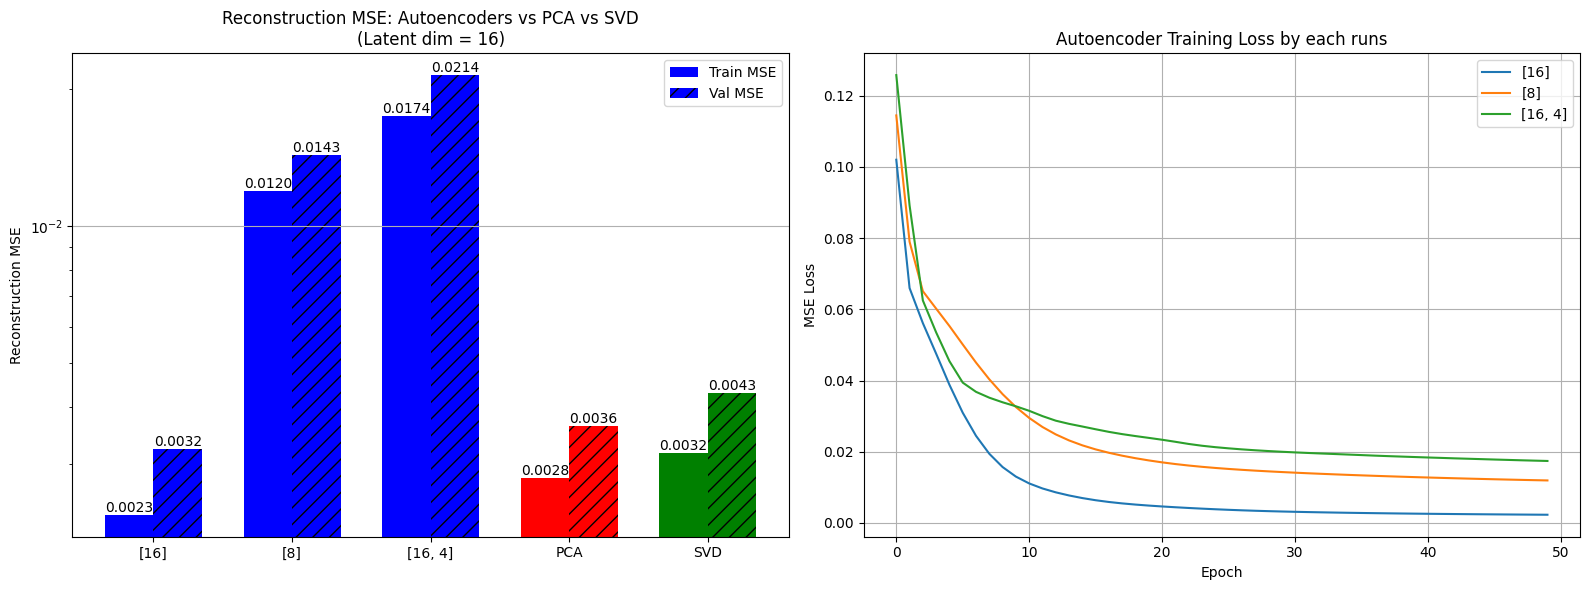


Method                       Train MSE     Test MSE
[16]                          0.002319     0.003235
[8]                           0.011954     0.014330
[16, 4]                       0.017422     0.021436
PCA                           0.002797     0.003641
SVD                           0.003165     0.004287


In [73]:
# Plot comparison
autoencoder_runs  = list(results.keys())[:-2] # Assuming the last two entries in results are PCA and SVD
all_runs = autoencoder_runs + ['PCA', 'SVD']

train_mses = [results[n]['train'] for n in all_runs]
test_mses  = [results[n]['val']  for n in all_runs]

x     = np.arange(len(all_runs))
width = 0.35
colors = ['blue'] * len(autoencoder_runs) + ['red', 'green'] # Blue is the autoencoder, Red is PCA, Green is SVD

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#Train vs Test MSE
bars1 = ax1.bar(x - width/2, train_mses, width, label='Train MSE', color=colors)
bars2 = ax1.bar(x + width/2, test_mses,  width, label='Val MSE', color=colors, hatch='//')
ax1.set_xticks(x)
ax1.set_xticklabels(all_runs)
ax1.set_ylabel('Reconstruction MSE')
ax1.set_title(f'Reconstruction MSE: Autoencoders vs PCA vs SVD\n(Latent dim = {LATENT_DIM})')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, axis='y')
for bar, v in zip(bars1, train_mses):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{v:.4f}', ha='center', va='bottom')
for bar, v in zip(bars2, test_mses):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{v:.4f}', ha='center', va='bottom')

# Loss curves (autoencoders only)
for result in results_minmax:
    ax2.plot(result['train_loss'], label=str(result['hidden_layers']))
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.set_title('Autoencoder Training Loss by each runs')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Method':<25} {'Train MSE':>12} {'Test MSE':>12}")
for name in all_runs:
    print(f"{name:<25} {results[name]['train']:>12.6f} {results[name]['val']:>12.6f}")